# Clustering Evaluation

            ## 1. Learning objectives

            - Compute silhouette from pairwise distances
- Interpret Davies-Bouldin and inertia
- Explain why internal metrics do not prove usefulness

            ## 2. Prerequisites

            Basic NumPy arrays, means, and two-dimensional scatter plots.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Compare clusterings when real data usually has no correct class label.

            ## 4. Real-world use cases

            - Exploratory customer grouping
- Representation learning
- Quality-control pattern discovery

            ## 5. Core intuition in simple language

            A good silhouette point is close to its own group and far from its nearest alternative group.

## 6. Mathematical foundation

            $$s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}.$$

            **Every symbol:**

            - $a(i)$ is point i's mean distance to its cluster.
- $b(i)$ is its smallest mean distance to another cluster.
- $s(i)$ is its silhouette in [-1,1].

            **Why the equation is needed:** It balances cohesion and separation on a comparable scale.

            **Small numerical example:** If a=2 and b=5, s=(5-2)/5=.6.

            **Connection to Python:** The scratch loop calculates a, b, and their normalized difference for every point.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Represent each observation as a feature vector
2. Scale features when units differ
3. Fit the structure-discovery rule
4. Evaluate stability and usefulness
5. Inspect the result visually and with domain knowledge

## 9. Implementation from scratch

We implement the smallest useful version in NumPy so every update remains visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def silhouette_scratch(features, labels):
    distances = np.linalg.norm(features[:, None, :] - features[None, :, :], axis=2)
    values = []
    for index, label in enumerate(labels):
        same = labels == label
        same[index] = False
        a = distances[index, same].mean() if same.any() else 0.0
        b = min(
            distances[index, labels == other].mean()
            for other in np.unique(labels) if other != label
        )
        values.append((b - a) / max(a, b) if max(a, b) else 0.0)
    return float(np.mean(values))

tiny = np.array([[0., 0.], [0., 1.], [5., 5.], [5., 6.]])
print("Tiny silhouette:", round(silhouette_scratch(tiny, np.array([0, 0, 1, 1])), 3))

Tiny silhouette: 0.859


## 10. Implementation using a standard library

Scikit-learn adds input validation, efficient routines, and a consistent estimator API.

## 11. Dataset loading and exploration

The lesson uses a small built-in or synthetic dataset with a fixed seed and no network dependency.

## 12. Data preprocessing

Features are standardized when distance or covariance would otherwise be dominated by measurement units.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Silhouette scratch=0.8378, library=0.8378; Davies-Bouldin=0.2257


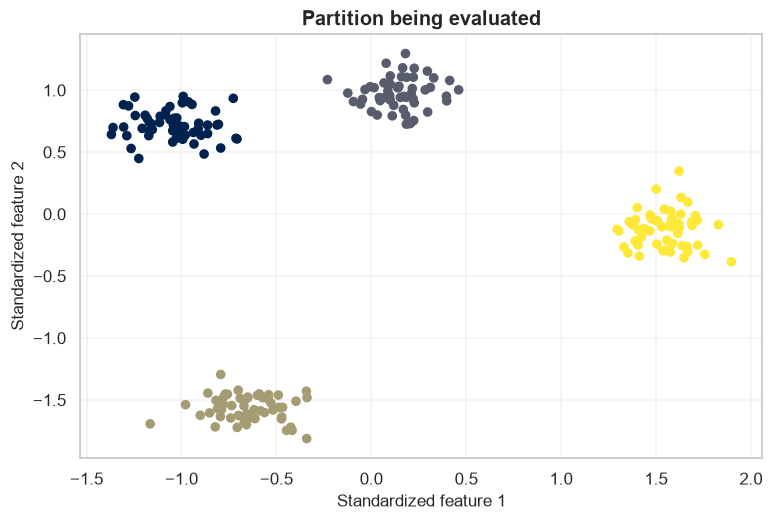

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

X, _ = make_blobs(n_samples=220, centers=4, cluster_std=.8, random_state=RANDOM_SEED)
X_scaled = StandardScaler().fit_transform(X)
labels = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_SEED).fit_predict(X_scaled)
scratch = silhouette_scratch(X_scaled, labels)
library = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
print(f"Silhouette scratch={scratch:.4f}, library={library:.4f}; Davies-Bouldin={db:.4f}")

figure, axis = plt.subplots()
axis.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap="cividis", s=28)
axis.set(title="Partition being evaluated", xlabel="Standardized feature 1", ylabel="Standardized feature 2")
plt.show()

**How to interpret the result:** High silhouette and low Davies-Bouldin support compact separation, not stable or actionable real-world segments.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Compare multiple metrics because each rewards a different geometric property.

,k,silhouette,Davies-Bouldin
0,2,0.571,0.552
1,3,0.764,0.348
2,4,0.838,0.226
3,5,0.704,0.539
4,6,0.600,0.715
5,7,0.465,0.920


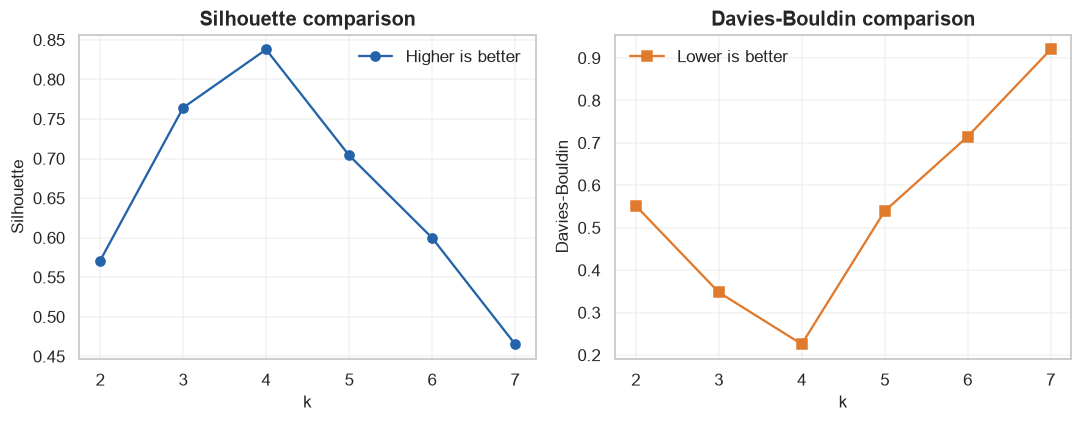

In [4]:
rows = []
for k in range(2, 8):
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit_predict(X_scaled)
    rows.append({"k": k, "silhouette": silhouette_score(X_scaled, labels_k), "Davies-Bouldin": davies_bouldin_score(X_scaled, labels_k)})
scores = pd.DataFrame(rows)
display(scores.round(3))
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(scores["k"], scores["silhouette"], marker="o", color=COURSE_COLORS["blue"], label="Higher is better")
axes[0].set(title="Silhouette comparison", xlabel="k", ylabel="Silhouette")
axes[0].legend()
axes[1].plot(scores["k"], scores["Davies-Bouldin"], marker="s", color=COURSE_COLORS["orange"], label="Lower is better")
axes[1].set(title="Davies-Bouldin comparison", xlabel="k", ylabel="Davies-Bouldin")
axes[1].legend()
figure.tight_layout()
plt.show()

## 18. Common mistakes

            - Treating cluster identifiers as ordered numbers
- Skipping scaling for distance-based methods
- Assuming an attractive grouping is automatically useful

            ## 19. Advantages and disadvantages

            **Advantages**

            - Does not require labels
- Can expose previously unknown structure

            **Disadvantages**

            - Evaluation is indirect
- Results can be sensitive to representation and hyperparameters

            ## 20. When to use and when not to use the algorithm

            **Use it when:** exploration, compression, or structure discovery is the goal and trustworthy labels are unavailable.

            **Do not use it when:** a supervised target directly represents the decision or the learned grouping has no domain interpretation.

## 21. Exercises

1. **Conceptual:** Why can cluster labels 0 and 1 not be interpreted as low and high?
2. **Mathematical/hand calculation:** Compute the Euclidean distance between (0, 0) and (3, 4).
3. **Coding/experimentation:** Change the random seed and check whether the structure is stable.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Cluster IDs are arbitrary names; permuting them does not change the grouping.
2. $\sqrt{3^2+4^2}=5$.
3. Rerun with several seeds and compare scores plus assignments; instability is evidence that conclusions need caution.

</details>

## 23. Summary and key takeaways

            - Unsupervised methods learn from features without fitting to labels
- Scaling and representation strongly affect results
- Metrics, visualization, stability, and domain usefulness must be considered together

            ## 24. Further reading

            - [scikit-learn clustering guide](https://scikit-learn.org/stable/modules/clustering.html)